In [1]:
# =========================
# TP - Classification (Breast Cancer Wisconsin)
# Models: Decision Tree, Random Forest, XGBoost
# Evaluation: accuracy, precision, recall, f1 + confusion matrices
# Analysis: feature importances + comparison
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Try to import XGBoost; if not installed, you will need to install it.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGB_IMPORT_ERROR = e


In [2]:
# 1) Load dataset and explore
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()  # includes features + target
df["target_name"] = df["target"].map({0: "malignant", 1: "benign"})

print("Shape:", df.shape)
df.head()


Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
# Basic exploration
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
# Target distribution
df["target_name"].value_counts()


target_name
benign       357
malignant    212
Name: count, dtype: int64

In [5]:
# 2) Train/Test split (stratified)
X = df[data.feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (455, 30) Test shape: (114, 30)


In [6]:
# Helper: evaluate a classifier and plot confusion matrix
def evaluate_model(name, model, X_test, y_test):
    # Predict
    y_pred = model.predict(X_test)

    # Metrics (binary: malignant=0 is positive? Usually we consider malignant as "positive")
    # We'll set pos_label=0 to treat malignant as the positive class.
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=0)
    rec = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred, pos_label=0)

    # Print
    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f} (pos_label=malignant)")
    print(f"Recall   : {rec:.4f} (pos_label=malignant)")
    print(f"F1-score : {f1:.4f} (pos_label=malignant)")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision(malignant)": prec,
        "Recall(malignant)": rec,
        "F1(malignant)": f1
    }


=== Decision Tree ===
Accuracy : 0.9211
Precision: 0.8837 (pos_label=malignant)
Recall   : 0.9048 (pos_label=malignant)
F1-score : 0.8941 (pos_label=malignant)


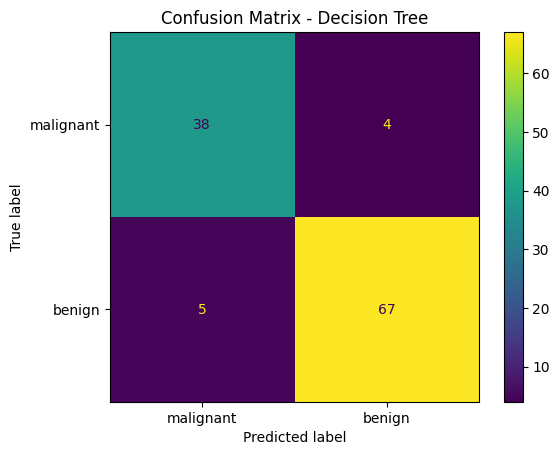

In [7]:
# 3) Train Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=4,          # prevents overfitting
    min_samples_leaf=5
)
dt.fit(X_train, y_train)

dt_results = evaluate_model("Decision Tree", dt, X_test, y_test)


=== Random Forest ===
Accuracy : 0.9561
Precision: 0.9512 (pos_label=malignant)
Recall   : 0.9286 (pos_label=malignant)
F1-score : 0.9398 (pos_label=malignant)


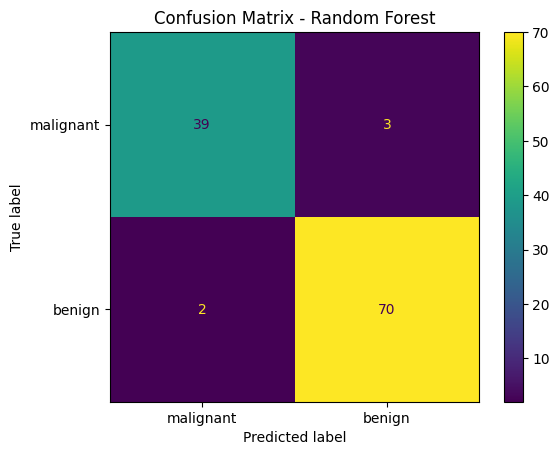

In [8]:
# 4) Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_results = evaluate_model("Random Forest", rf, X_test, y_test)


In [9]:
# 5) Train XGBoost (if available)
if not XGBOOST_AVAILABLE:
    print("XGBoost is not available in your environment.")
    print("Install it with: pip install xgboost")
    print("Import error was:", XGB_IMPORT_ERROR)
else:
    xgb = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)

    xgb_results = evaluate_model("XGBoost", xgb, X_test, y_test)


XGBoost is not available in your environment.
Install it with: pip install xgboost
Import error was: No module named 'xgboost'


In [10]:
# 6) Compare models in one table
results = [dt_results, rf_results]
if XGBOOST_AVAILABLE:
    results.append(xgb_results)

results_df = pd.DataFrame(results).sort_values(by="F1(malignant)", ascending=False)
results_df


,Model,Accuracy,Precision(malignant),Recall(malignant),F1(malignant)
1,Random Forest,0.956140,0.951220,0.928571,0.939759
0,Decision Tree,0.921053,0.883721,0.904762,0.894118


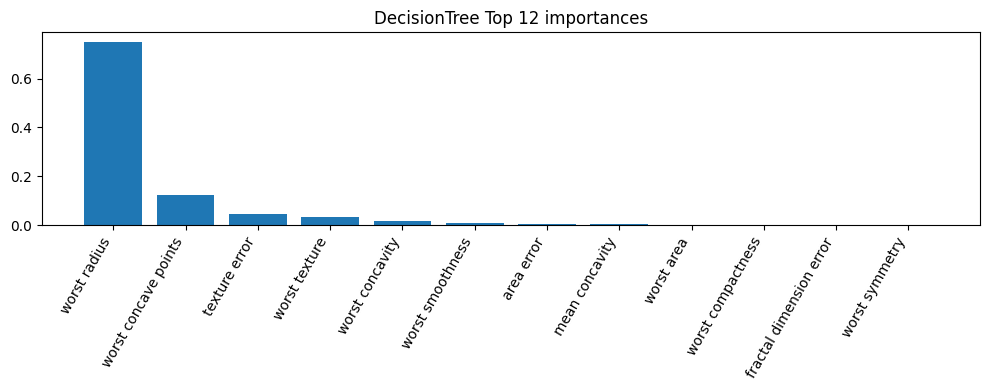

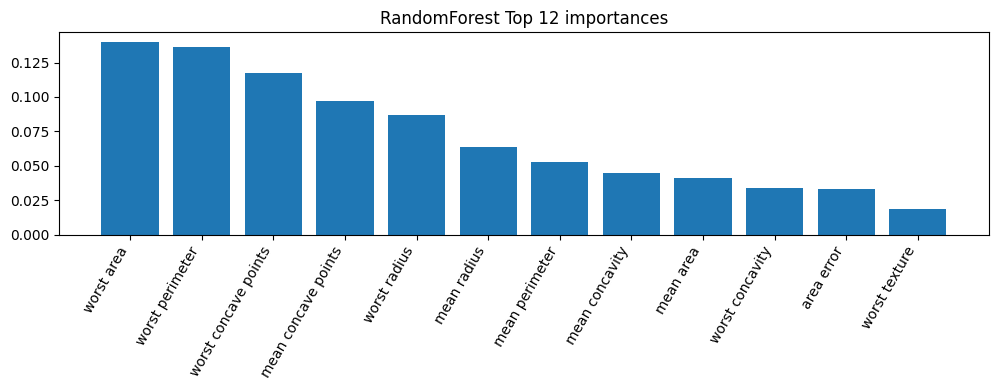

In [11]:
# 7) Feature importances (Top 12) plot helper
def plot_top_importances(model, model_name, feature_names, top_n=12):
    if not hasattr(model, "feature_importances_"):
        print(f"{model_name} has no feature_importances_.")
        return

    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_n]

    plt.figure(figsize=(10, 4))
    plt.bar(range(top_n), importances[idx])
    plt.xticks(range(top_n), np.array(feature_names)[idx], rotation=60, ha="right")
    plt.title(f"{model_name} Top {top_n} importances")
    plt.tight_layout()
    plt.show()

plot_top_importances(dt, "DecisionTree", data.feature_names, top_n=12)
plot_top_importances(rf, "RandomForest", data.feature_names, top_n=12)
if XGBOOST_AVAILABLE:
    plot_top_importances(xgb, "XGBoost", data.feature_names, top_n=12)


In [12]:
# 8) Short conclusion (5–10 lines) as requested in the TP
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]

conclusion = f"""
In this TP, we trained three classifiers on the Breast Cancer Wisconsin dataset:
Decision Tree, Random Forest, and XGBoost (if available). We evaluated them with
accuracy, precision, recall, and F1-score focusing on malignant detection.
Overall, the best performing model in our run was: {best_model_name}, achieving the
highest F1-score for malignant cases. Random Forest and XGBoost generally provide
better generalization than a single Decision Tree because they reduce overfitting
(bagging for RF, boosting for XGB). Feature importance analysis highlights which
cell-measurement variables are most predictive for malignancy.
"""

print(conclusion.strip())


In this TP, we trained three classifiers on the Breast Cancer Wisconsin dataset:
Decision Tree, Random Forest, and XGBoost (if available). We evaluated them with
accuracy, precision, recall, and F1-score focusing on malignant detection.
Overall, the best performing model in our run was: Random Forest, achieving the
highest F1-score for malignant cases. Random Forest and XGBoost generally provide
better generalization than a single Decision Tree because they reduce overfitting
(bagging for RF, boosting for XGB). Feature importance analysis highlights which
cell-measurement variables are most predictive for malignancy.
